# **📊 Abandono de clientes en telecomunicaciones para pronosticar y prevenir la pérdida de clientes🚀**

**Por:** Luz Alizon Mamani Mena

# **Carga de datos y comprobaciones de validación 🔎**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("fivethirtyeight")

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

In [ ]:
print("Shape:", df.shape)

In [ ]:
df.info()

In [ ]:
df.nunique()

# **Limpieza de Datos 🧹**
**Manejo de valores faltantes**

In [ ]:
print("\nDatos Faltantes:")
print(df.isnull().sum())

In [ ]:
print("Número total de duplicados por customerID: {}"
      .format(df.duplicated(subset=['customerID']).sum()))

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].astype('float')
df.info()

In [ ]:
#Grafico que permite observar los datos nulos
import missingno as msno
msno.matrix(df)

In [ ]:
df.isnull().sum()

# **Análisis exploratorio de datos 🕵️‍♀️**

En esta sección, exploraremos diversas cuestiones planteadas anteriormente y comprobaremos las hipótesis relativas a los valores faltantes.

En primer lugar, separaremos los datos en variables categóricas y numéricas. A continuación, realizaremos un análisis estadístico descriptivo y examinaremos la correlación entre los cargos totales, la antigüedad y los cargos mensuales.

In [ ]:
# Separar características categóricas y numéricas
categorical_data = df.select_dtypes(include=['object']).columns.tolist()
numerical_data = df.select_dtypes(exclude=['object']).columns.tolist()
categorical_enc_features= ['SeniorCitizen']

# Excluir 'CustomerID' y Churn de las características categóricas
ex=['customerID','Churn']
categorical_features = [feature for feature in categorical_data if feature not in ex]

# Excluir 'SeniorCitizen' de las características numéricas
ex=['SeniorCitizen']
numerical_features = [feature for feature in numerical_data if feature not in ex]

# Imprimir características categóricas, numéricas y codificadas categóricamente
print("Caracteristicas categoricas:", categorical_features,'\n')
print("Caracteristicas numéricas:", numerical_features,'\n')
print("Codificadas categóricamente:", categorical_enc_features,'\n')

In [ ]:
df[numerical_features].describe()

In [ ]:
import plotly.express as px

cols_to_correlate = ['TotalCharges', 'MonthlyCharges', 'tenure']
corr_matrix = df[cols_to_correlate].corr()

fig1 = px.imshow(corr_matrix,
                 text_auto=True,
                 aspect='auto',
                 title='Mapa de calor: Correlación entre Total Charges,<br>Monthly Charges y Tenure',
                 color_continuous_scale=px.colors.sequential.Viridis)

fig1.update_layout(plot_bgcolor='rgba(0,0,0,0)',
                   paper_bgcolor='rgba(0,0,0,0)',
                   font_color='black',
                   width=500,
                   height=350)
fig1.show()

Suponemos que el cargo total se determina principalmente por el producto del cargo mensual y la antigüedad. Esto se basa en la lógica de negocio de que el total de cargos de un cliente durante su periodo de suscripción debería ser aproximadamente igual a su cargo mensual multiplicado por el número de meses que ha estado activo.

Comprobemos esta suposición examinando si el cargo total se puede aproximar mediante el producto del cargo mensual y la antigüedad.

In [ ]:
df_new = df[numerical_features].copy()
df_new['MonthlyCharges_x_tenure'] = df_new['MonthlyCharges'] * df_new['tenure']
correlation = df_new[['TotalCharges', 'MonthlyCharges_x_tenure']].corr().iloc[0,1]
print("Correlación entre TotalCharges y MonthlyCharges * tenure:", correlation)

In [ ]:
import plotly.express as px

# Gráfico simple de dispersión con línea de regresión
fig2 = px.scatter(df_new, x='MonthlyCharges_x_tenure', y='TotalCharges',
                 title=f'Relación entre TotalCharges y MonthlyCharges*tenure<br>Correlación: {correlation:.4f}',
                 trendline="ols",  # Línea de regresión
                 trendline_color_override="red",
                 opacity=0.5)

fig2.update_layout(
    title={'x': 0.5, 'xanchor': 'center', 'font': {'size': 16}},
    xaxis_title='MonthlyCharges * tenure',
    yaxis_title='TotalCharges',
    width=500,
    height=350,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='black'
)

fig2.show()

La correlación entre el total de cargos y el producto de los cargos mensuales por la duración del contrato es de **0,99955**, lo que indica una relación lineal **casi perfecta**. Esto respalda nuestra suposición inicial de que el total de cargos se determina esencialmente al multiplicar los cargos mensuales por la duración del contrato. Cualquier ligera desviación de esta correlación perfecta puede deberse a factores como descuentos, ofertas promocionales u otros ajustes aplicados antes del registro final del total de cargos.

Analicemos las filas donde faltan valores en el total de cargos y examinemos cómo se presentan su duración y los cargos mensuales.

In [ ]:
#Filtrar filas con valores faltantes en TotalCharges
missing_totalcharges = df[df['TotalCharges'].isna()]

print("Número de filas con valores faltantes en Total Charges:", len(missing_totalcharges))

missing_totalcharges[['TotalCharges', 'tenure', 'MonthlyCharges','Churn']].head()

In [ ]:
#Compruebe las filas donde falte TotalCharges y tenure = 0.
missing_with_tenure0 = missing_totalcharges[missing_totalcharges['tenure'] == 0]

print("Número de filas donde falta TotalCharges y tenure is 0:", len(missing_with_tenure0))
missing_with_tenure0[['TotalCharges', 'tenure', 'MonthlyCharges']].head()

Los valores faltantes en TotalCharges corresponden a clientes con una antigüedad de 0, lo que indica que son clientes nuevos que aún no han completado su primer mes de suscripción. Por lo tanto, los valores faltantes no se deben a cancelaciones de suscripción. Esto se ve reforzado por el hecho de que estos clientes no se dieron de baja.

**ALGUNOS GRÁFICOS**

In [ ]:
import plotly.express as px

fig3 = px.scatter(df, x='MonthlyCharges', y='TotalCharges',
                 title='Total Charges vs Monthly Charges',
                 labels={'MonthlyCharges': 'Monthly Charges',
                        'TotalCharges': 'Total Charges'},
                 color_discrete_sequence=['green'],
                 opacity=0.7)  # Añadir transparencia

fig3.update_layout(
    title={'x': 0.5, 'xanchor': 'center', 'font': {'size': 20}},
    xaxis_title='Monthly Charges',
    yaxis_title='Total Charges',
    template='plotly_white',
    width=500,
    height=350,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='black'
)

# Personalizar los marcadores
fig3.update_traces(marker=dict(size=8,
                              line=dict(width=1, color='black')))

fig3.show()

In [ ]:
import plotly.express as px

# Conversión directa a Plotly
fig4 = px.scatter(df, x='tenure', y='TotalCharges',
                 title='Total Charges vs Tenure',
                 labels={'tenure': 'Tenure',
                        'TotalCharges': 'Total Charges'},
                 color_discrete_sequence=['purple'],
                  opacity=0.7)

# Configuración del layout
fig4.update_layout(
    title={'x': 0.5, 'xanchor': 'center', 'font': {'size': 20}},
    xaxis_title='Tenure',
    yaxis_title='Total Charges',
    template='simple_white',
    width=500,
    height=350,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='black'
)

fig4.show()

**Análisis:**
En el gráfico anterior, se observa una fuerte correlación entre los *TotalCharges* y *Tenure*, así como entre los *TotalCharges* y los *TotalMontly*. A medida que aumentan el *tenure* y los *TotalMontly*, los *TotalCharges* también tienden a incrementarse. Este patrón sugiere la presencia de multicolinealidad entre estas variables.

A continuación, imputaremos los valores faltantes en TotalCharges con 0, ya que estos corresponden a nuevos clientes cuyos cargos totales aún no se han acumulado.

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
# Obtén el índice de las filas con datos faltantes TotalCharges
missing_index = missing_totalcharges.index

# Comprueba esas filas en el dataframe original.
df.loc[missing_index, ['TotalCharges', 'tenure', 'MonthlyCharges']]

In [ ]:
# Comprobar la correlación entre las características numéricas después de la imputación
corr_num = df[numerical_features].corr()
print("Correlacion entre Total Charges, Monthly Charges, and Tenure:")
display(corr_num)

Tras imputar los valores faltantes del atributo TotalCharges, la correlación entre TotalCharges y las características MonthlyCharges y Tenure tiende a mantenerse casi igual que antes de la imputación, salvo la variacion en algunos decimales.

A continuación, analizaremos la distribución de la tasa de abandono.

In [ ]:
#Tasa de abandono de servicios
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(5, 5))
wedges, texts, autotexts = plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("husl", 8)[0:2])
plt.title('Distribución de Churn', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Add counts as text labels
for i, count in enumerate(churn_counts):
    # Get the position of the autotext (percentage label)
    x, y = autotexts[i].get_position()
    # Calculate a new position slightly further out
    angle = np.deg2rad((wedges[i].theta2 + wedges[i].theta1) / 2.)
    x_text = x + 0.15 * np.cos(angle)
    y_text = y + 0.15 * np.sin(angle)

    plt.text(x_text, y_text,
             f'{count}',
             horizontalalignment='center',
             verticalalignment='center',
             fontsize=12,
             color='black')

plt.show()

**Análisis:**

Existe un desequilibrio entre las clases de clientes que se dan de baja y los que no. Esta situación puede generar sesgos en las predicciones, ya que los resultados tenderán a ser más precisos para la clase mayoritaria.

In [ ]:
#Distribucion de los cargos mensuales por Churn
colors = ['#9BC0DA', '#ed1f91']

plt.figure(figsize=(8,6))
sns.histplot(data=df,
             x='MonthlyCharges',
             hue='Churn',
             kde=True,
             palette=colors,
             alpha=0.6)

# Remove grid
plt.grid(False)

plt.title('Distribución de cargos mensuales por Churn', fontsize=14)
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
from scipy.stats import spearmanr

# Conversión de la columna 'Churn' de categórica a numérica
mapping = {'No': 0, 'Yes': 1}
df_cor = df.copy()
df_cor['Churn'] = df_cor['Churn'].map(mapping)

# Calcular la correlación de Spearman entre los cargos mensuales y la tasa de abandono.
corr, p_val = spearmanr(df_cor['MonthlyCharges'], df_cor['Churn'])

print(f"Spearman Correlation: {corr:.4f}")
print(f"P-value: {p_val:.4f}")

**Análisis:**

La distribución de los cargos mensuales para clientes que cancelaron su suscripción y los que no, parece similar, mostrando una distribución no normal con un pico alrededor de los 80-100 dólares.

El análisis de correlación revela una relación positiva entre los cargos mensuales y el estado de cancelación. A medida que aumentan los cargos mensuales, la probabilidad de que un cliente cancele su suscripción aumenta ligeramente. Sin embargo, dado que el coeficiente de correlación es inferior a 0,3, esta relación se considera débil.

Con un p-value de 0,0000 (muy por debajo del nivel de significancia de 0,05), la asociación positiva es estadísticamente significativa y es poco probable que se deba al azar.

In [ ]:
colors = ['#8eb716', '#3d4324']

plt.figure(figsize=(8,6))
sns.histplot(data=df,
             x='tenure',
             hue='Churn',
             kde=True,
             palette=colors,
             alpha=0.6)

# Remove grid
plt.grid(False)

plt.title('Distribucion de Tenure por Churn', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
# Calcular la correlación de Spearman entre la Tenure y Churn
corr, p_val = spearmanr(df_cor['tenure'], df_cor['Churn'])

print(f"Spearman Correlation: {corr:.4f}")
print(f"P-value: {p_val:.4f}")

**Análisis:**

La distribución de la antigüedad de los clientes que se dan de baja tiende a presentar una asimetría positiva, mientras que la de los clientes que no se dan de baja tiende a presentar una asimetría negativa.

Los clientes que se dan de baja suelen ser aquellos con menos de un año de suscripción.

El análisis de correlación revela una fuerte relación negativa entre la antigüedad y la baja del servicio. A mayor antigüedad, menor probabilidad de churn.

Con un ***p-value de 0,0000*** (muy por debajo del nivel de significancia de 0,05), la asociación negativa es estadísticamente significativa y es poco probable que se deba al azar.

In [ ]:
colors = ['#3B200B', '#D76F02']

plt.figure(figsize=(8,6))
sns.histplot(data=df,
             x='TotalCharges',
             hue='Churn',
             kde=True,
             palette=colors,
             alpha=0.6)

# Remove grid
plt.grid(False)

plt.title('Distribucion del Cargos Totales por Churn', fontsize=14)
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
corr, p_val = spearmanr(df_cor['TotalCharges'], df_cor['Churn'])

print(f"Spearman Correlation: {corr:.4f}")
print(f"P-value: {p_val:.4f}")

**Análisis:**

La distribución de los Cargos Totales, tanto para clientes que cancelaron su suscripción como para aquellos que no, presenta una asimetría positiva. Esto es similar a la distribución de la antigüedad entre los clientes que cancelaron su suscripción.

Los clientes con cargos totales elevados suelen ser suscriptores leales a largo plazo (alta antigüedad), ya que los cargos totales representan los costos acumulados durante su periodo de suscripción, y los clientes a largo plazo tienden a ser más leales, lo que reduce la probabilidad de que cancelen su suscripción.

El análisis de correlación muestra una relación negativa moderada entre los Cargos Totales y la cancelación de la suscripción, con un coeficiente de correlación de Spearman de -0,2300. Esto indica que, a medida que aumentan los cargos totales, la probabilidad de que un cliente cancele su suscripción tiende a disminuir.

Con un valor p de 0,0000 (muy por debajo del nivel de significancia de 0,05), esta asociación negativa es estadísticamente significativa y es poco probable que se deba al azar.

A continuación, examinaremos la distribución de la cancelación de la suscripción según el género y la edad (adultos mayores).

In [ ]:
gender_counts = df['gender'].value_counts(normalize=True)

# Crea un nuevo DataFrame a partir de los recuentos de valores.
gender_distribution = pd.DataFrame({
    'Total Count': df['gender'].value_counts(),
    'Percentage': (gender_counts * 100).round(2)
})

display(gender_distribution)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Consultar el DataFrame para separar los datos de clientes que no se han dado de baja y clientes que sí lo han hecho.
query_female = df.query('gender=="Female"')
query_male = df.query('gender=="Male"')

def val_counts(df, var):
    results = df[var].value_counts(sort=False)
    labels = results.index
    counts = results.values
    return labels, counts

labels_female = val_counts(query_female, 'Churn')[0].tolist()

# Changing the values 'No' to 'No Churn' and 'Yes' to 'Churn'
labels_female = ['No Churn' if label == 'No' else 'Churn' for label in labels_female]
values_female = val_counts(query_female, 'Churn')[1]

labels_male = val_counts(query_male, 'Churn')[0]
# Cambiar los valores 'No' a 'No Churn' y 'Yes' to 'Churn'
labels_male = ['No Churn' if label == 'No' else 'Churn' for label in labels_male]
values_male = val_counts(query_male, 'Churn')[1]

# Definir colores (añade esta línea)
colors = ['#78E03F', '#9E82E0']  # o los colores que prefieras

# Create subplots: use 'domain' type for Pie subplot
fig5 = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])

fig5.add_trace(go.Pie(labels=labels_female, values=values_female,
                     marker=dict(colors=colors),
                     name="Female"
                    ),
              row=1, col=1)

fig5.add_trace(go.Pie(labels=labels_male, values=values_male,
                     marker=dict(colors=colors),
                     name="Male"
                    ),
              row=1, col=2)

# Creacion de graficos
fig5.update_traces(hole=.4, hoverinfo="label+value+percent+name")

fig5.update_layout(
    title_text="Distribución del Churn por Género",
    title_x=0.5, # Centrar el título
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='black',
    width=600,
    height=400,

    # Add annotations in the center of the donut pies.
    annotations=[dict(text='Female', x=0.18, y=0.5, font_size=15, showarrow=False),
                 dict(text='Male', x=0.80, y=0.5, font_size=15, showarrow=False)],

    # Adjusting the position of legend
    legend=dict(
        x=0.5, y=1.1, xanchor='center',
        orientation='h',  # Horizontal orientation
        bgcolor='rgba(211,211,211,0.3)',  # legend background color
        font=dict(size=12)
    )
)

# SOLUCIÓN: Cambiar esta línea
fig5.show()

**Conclusiones:**

El porcentaje de hombres y mujeres no difiere significativamente, y el número de casos de abandono según el género también es similar. Por lo tanto, podemos concluir que el género no influye en el abandono.

A continuación, crearemos visualizaciones mediante un gráfico de barras apiladas. Optamos por este tipo de gráfico porque nos permite visualizar la proporción de abandono dentro de diferentes categorías o segmentos. A diferencia de un gráfico de barras convencional, que muestra únicamente el recuento total o la proporción de cada categoría por separado, un gráfico de barras apiladas ofrece información sobre la contribución relativa de las diversas subcategorías dentro de cada categoría principal.

In [ ]:
ct_senior_citizen= pd.crosstab(index=df['SeniorCitizen'],
                               columns=df['Churn'])
ct_senior_citizen

In [ ]:
ct_senior_citizen_prob= pd.crosstab(index=df['SeniorCitizen'],
                               columns=df['Churn'],normalize='index')
ct_senior_citizen_prob

In [ ]:
# Representación gráfica del gráfico de barras apiladas
colors = ['#A23B72', '#F18F01']
ct_senior_citizen_prob.plot(kind='bar', stacked=True, color=colors, figsize=(8, 6))

# Agregar leyenda y etiquetas
plt.legend(['Not Churn', 'Churn'],
           loc="upper center",
           ncol=2,
           bbox_to_anchor=(0.5, 1.15),
           title="Estado de Churn por Genero")

plt.xlabel("Senior Citizen")
plt.ylabel("Proportion")

# Agregar anotaciones
for n, x in enumerate([*ct_senior_citizen.index.values]):
    for (proportion, count, y_loc) in zip(ct_senior_citizen_prob.loc[x],
                                          ct_senior_citizen.loc[x],
                                          ct_senior_citizen_prob.loc[x].cumsum()):
        plt.text(x=n - 0.1,
                 y=(y_loc - proportion) + (proportion / 2),
                 s=f'{count}\n({np.round(proportion * 100, 1)}%)',
                 color="black",
                 fontsize=12,
                 fontweight="bold")

# Girar etiquetas del eje x
plt.xticks(rotation=0)
plt.show()

A partir de los resultados de la visualización, podemos concluir lo siguiente: La tasa de abandono entre los clientes clasificados como adultos mayores es del 41,7 %, mientras que entre quienes no lo son es del 23,6 %. Esto sugiere que los adultos mayores tienden a tener una tasa de abandono más alta en comparación con los demás usuarios.

Los adultos mayores representan un segmento de clientes más pequeño, pero contribuyen de manera desproporcionada al abandono. Esto sugiere que este grupo puede enfrentar dificultades con el servicio, los precios o la adopción de tecnología, lo que aumenta la probabilidad de que se den de baja.

Las empresas de telecomunicaciones deberían diseñar estrategias de retención específicas para los clientes mayores, tales como:

* Ofrecer planes o paquetes de servicio simplificados y adaptados a las necesidades de los clientes mayores.
* Brindar una mejor atención al cliente y orientación para el uso de los servicios digitales.
* Implementar programas de fidelización o incentivos específicos para usuarios mayores con el fin de reducir el abandono.

In [ ]:
def stacked_bar_chart(ax, ct_index, ct_columns, xlabel, ylabel, colors, color_text='black', fontsize=12):
    """
    Create a stacked bar chart with counts and percentage annotations.

    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axes to plot on.
    ct_index : pd.Series
        Categories for the x-axis.
    ct_columns : pd.Series
        Categories for the stacked bars.
    xlabel : str
        Label for x-axis.
    ylabel : str
        Label for y-axis.
    colors : list
        List of colors for the stacked bars.
    color_text : str, optional
        Text color for annotations (default is 'black').
    fontsize : int, optional
        Font size for annotations (default is 12).
    """

    # Crosstab for counts
    ct_data_count = pd.crosstab(index=ct_index, columns=ct_columns)

    # Crosstab for proportions
    ct_data_prob = pd.crosstab(index=ct_index, columns=ct_columns, normalize='index')

    # Plot stacked bar chart
    ct_data_prob.plot(kind='bar', stacked=True, color=colors, ax=ax)

    # Labels
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(ct_data_prob.index.values, rotation=0)
    ax.grid(axis='x', linestyle='', linewidth=0)

    # Add counts and percentages
    for n, category in enumerate(ct_data_prob.index.values):
        y_offset = 0
        for (proportion, count) in zip(ct_data_prob.loc[category], ct_data_count.loc[category]):
            if proportion > 0:  # avoid placing text on 0% bars
                ax.text(
                    x=n,
                    y=y_offset + proportion / 2,
                    s=f'{count}\n({proportion * 100:.1f}%)',
                    ha='center',
                    color=color_text,
                    fontsize=fontsize,
                    fontweight="bold"
                )
            y_offset += proportion

In [ ]:
list_attributes=['Partner','Dependents']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
title="Churn Status"

for idx, attribute in enumerate(list_attributes):
    stacked_bar_chart(ax[idx],df[attribute],df['Churn'],
                      xlabel= attribute, ylabel='Proportion',
                      colors=colors)
    ax[idx].legend(['Not Churn', 'Churn'],
               loc="upper center", ncol=2,
               bbox_to_anchor=(0.5, 1.3),
               title=title)

plt.tight_layout()
plt.show()

**Análisis:**

La tasa de abandono entre los clientes con pareja es del 19,7 %, mientras que entre los que no la tienen es del 33 %.

La tasa de abandono entre los clientes con personas a su cargo es del 15,5 %, mientras que entre los que no las tienen es del 31,3 %.

Estos patrones podrían deberse a que las personas con pareja y personas a su cargo suelen tener mayores necesidades de telecomunicaciones, lo que reduce la probabilidad de que cancelen el servicio en comparación con quienes no tienen pareja ni personas a su cargo.

# **HIPOTESIS**

Ahora, analizaremos si existe una relación entre "MultipleLines" y "Churn":

**Hipótesis nula (H0):** No existe relación entre la variable MultipleLines y Churn.

**Hipótesis alternativa (H1):** Existe una relación entre la variable MultipleLines y Churn.

In [ ]:
# Crea una tabla de contingencias
contingency_table = pd.crosstab(df['MultipleLines'], df['Churn'])
contingency_table

In [ ]:
from scipy.stats import chi2_contingency
from typing import List

def chi_square_test(
    df: pd.DataFrame,
    target: str,
    features: List[str],
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Perform Chi-square tests for categorical features against a target variable.

    Parameters:
        df (pd.DataFrame): The input dataframe containing the data.
        target (str): The target column name.
        features (List[str]): List of feature column names to test.
        alpha (float): Significance level (default is 0.05).

    Returns:
        pd.DataFrame: A DataFrame containing p-values and test results.
    """
    results = []
    for feature in features:
        # Crear tabla de contingencia
        contingency_table = pd.crosstab(df[feature], df[target])

        # Realizar la prueba de chi-cuadrado
        chi2, p_value, _, _ = chi2_contingency(contingency_table)

        # Calculate Cramér's V
        n = contingency_table.sum().sum()
        min_dim = min(contingency_table.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim))

        # Interpretar la fuerza de la relación
        if cramers_v <= 0.10:
            strength = "Muy debil"
        elif cramers_v <= 0.30:
            strength = "Debil"
        elif cramers_v <= 0.50:
            strength = "Moderado"
        else:
            strength = "Fuerte"

        # Interpretación de pruebas de hipótesis
        reject_h0 = "si" if p_value <= alpha else "no"

        # Agregar resultados
        results.append({
            'característica': feature,
            'objetivo': target,
            "chi2": round(chi2, 4),
            'p-value': round(p_value, 4),
            'rechazar_h0': reject_h0,
            'cramers_v': round(cramers_v, 4),
            'fuerza_de_la_relación': strength
        })

    # Create DataFrame
    output_df = pd.DataFrame(results)
    return output_df

target = 'Churn'
features = ['MultipleLines']
output_table = chi_square_test(df, target, features)
display(output_table)

**Análisis:**

Según la prueba de chi-cuadrado y la V de Cramér, existe una relación estadísticamente significativa entre las *MultipleLines* y *Churn* (valor p = 0,0035). Sin embargo, la fuerza de esta asociación es ***muy débil*** (V de Cramér = 0,0401). Esto indica que, si bien existe una diferencia en las tasas de abandono entre los clientes con y sin líneas múltiples, su impacto práctico es mínimo. Es probable que otros factores influyan más en la tasa de abandono de clientes.

In [ ]:
list_attributes=['PhoneService','InternetService','StreamingTV','StreamingMovies']

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16, 10),
                       gridspec_kw={'hspace': 0.7}
                      )

for idx, attribute in enumerate(list_attributes):
    row_idx = idx // 2  # Calculate the row index
    col_idx = idx % 2   # Calculate the column index
    stacked_bar_chart(ax[row_idx][col_idx], df[attribute], df['Churn'],
                      xlabel=attribute, ylabel='Proportion',
                      colors=colors)

    ax[row_idx][col_idx].legend(['Not Churn', 'Churn'],
               loc="upper center", ncol=2,
               bbox_to_anchor=(0.5, 1.3),
               title=title)

plt.tight_layout()
plt.show()

In [ ]:
target = 'Churn'
features = list_attributes
output_table = chi_square_test(df, target, features)
display(output_table)

**Conclusiones:**

Basándonos en la visualización y el análisis mediante la prueba de chi-cuadrado, podemos concluir lo siguiente:

* Los clientes con o sin servicio telefónico presentan tasas de abandono similares, lo que indica que la variable "Servicio Telefónico" no influye significativamente en el abandono. Este hallazgo también se ve respaldado por la prueba estadística de chi-cuadrado.

* Los clientes que utilizan servicios de internet, especialmente aquellos con fibra óptica, tienden a tener una alta tasa de abandono del 41,9%, mientras que los clientes con DSL o sin servicio de internet tienden a tener una tasa de abandono inferior al 20%.

* Según la prueba de chi-cuadrado y el análisis V de Cramér, la variable "Servicio de Internet" muestra una relación moderada con el abandono. Esto sugiere que las empresas de telecomunicaciones deberían investigar más a fondo por qué los clientes que utilizan servicios de internet, en particular aquellos con conexiones de fibra óptica, presentan tasas de abandono relativamente altas.

* Tanto los clientes con servicio de internet y suscripción a televisión en streaming como aquellos sin suscripción presentan tasas de abandono similares (alrededor del 30%). Esto sugiere que la tasa de abandono podría no deberse a la suscripción a la televisión en streaming, sino a un servicio de internet de fibra óptica deficiente.

* De manera similar, en el caso de las películas en streaming, las tasas de abandono no difieren significativamente entre los clientes que tienen contratado tanto el servicio de internet como las películas en streaming. Esto sugiere que la alta tasa de abandono entre los suscriptores de películas en streaming podría deberse a que la mayoría de estos clientes utiliza fibra óptica.

* Según la prueba de chi-cuadrado y el análisis V de Cramér, las variables Películas en Streaming y Televisión en Streaming están correlacionadas con la tasa de abandono. Sin embargo, esta relación podría estar influenciada por la variable del servicio de internet, ya que ambos servicios de streaming probablemente dependen del tipo de conexión, como fibra óptica o DSL.

A continuación, analizaremos si la mayoría de los clientes que se suscribieron a Películas en Streaming y Televisión en Streaming y que han cancelado su suscripción son usuarios de fibra óptica. Este análisis se realizará mediante un gráfico de barras apiladas y un gráfico radial.

In [ ]:
# colors=['#a2b4fc','#ed1f91']

fig6 = px.sunburst(df.query("Churn=='Yes'"),
                  path=['StreamingTV','InternetService'], color='StreamingTV',
                  color_discrete_map={'No':'black', 'Yes':'#E04AD4', 'No internet service':'#00E0A4'})

# Adding text to each group
fig6.update_traces(textinfo='label + percent entry',
                  insidetextorientation='horizontal',
                  textfont_size=12)

# Adding a suitable titleQ
fig6.update_layout(title='Distribución de clientes churn por suscripción<br>a streamingTV y servicio de internet.',
                   width=500,
                   height=400,
                   plot_bgcolor='rgba(0,0,0,0)',
                   paper_bgcolor='rgba(0,0,0,0)',
                   font_color='black',
                 title_x=0.5)


fig6.show()

**Análisis:**

Según los resultados de la visualización, es evidente que la mayoría de los clientes suscritos a TV o películas en streaming utilizan fibra óptica.

Estos hallazgos refuerzan la sospecha de que la alta tasa de cancelación se relaciona más probablemente con la calidad o la satisfacción con el servicio de fibra óptica que con la suscripción al servicio de streaming en sí.

A continuación, analizaremos la tasa de cancelación según las condiciones del contrato.

In [ ]:
churn_rates = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
churn_rates.columns = ['Duracion Contrato', 'Tasa de Abandono (%)']
churn_rates

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Crear el gráfico de barras con Plotly
fig7 = px.bar(churn_rates,
             x='Duracion Contrato',
             y='Tasa de Abandono (%)',
             color='Duracion Contrato',  # Para aplicar colores diferentes
             color_discrete_sequence=['#043150', '#8BD1B4', '#03848C'],
             title='Tasa de abandono por duracion del contrato')

# Añadir etiquetas en las barras
fig7.update_traces(texttemplate='%{y:.1f}%',
                  textposition='outside',
                  textfont=dict(size=12, weight='bold'),
                  marker_line_color='black',
                  marker_line_width=1)

# Personalizar el layout
fig7.update_layout(
    title={'x': 0.5, 'xanchor': 'center', 'font': {'size': 16}},
    xaxis_title='Contract Term',
    yaxis_title='Churn Rate (%)',
    showlegend=False,  # Ocultar leyenda ya que los colores son por categoría
    template='plotly_white',
    width=500,
    height=350,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='black',
    yaxis=dict(range=[0, churn_rates['Tasa de Abandono (%)'].max() + 10],
               gridcolor='lightgray', gridwidth=1, griddash='dash')
)

# Añadir grid horizontal
fig7.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

fig7.show()

In [ ]:
target = 'Churn'
features = ['Contract']
output_table = chi_square_test(df, target, features)
display(output_table)

**Análisis:**

El tipo de contrato (mensual, anual o mayor o igual a dos años) influye significativamente en la tasa de cancelación de clientes, como lo indica el valor V de Cramér de 0,4101, que refleja una relación ***moderadamente sólida***.

Los clientes con contratos mensuales presentan la mayor tasa de cancelación, con un 42,7%. Esto indica que casi la mitad de los clientes con este tipo de contrato optan por cancelar el servicio. Esto es previsible, ya que los contratos mensuales ofrecen flexibilidad y permiten a los clientes darse de baja en cualquier momento.

Los clientes con contratos anuales tienen una tasa de cancelación significativamente menor, del 11,3%, lo que demuestra que estos contratos brindan mayor estabilidad y fomentan la fidelización.

Los clientes con contratos mayoro igual a dos años presentan la menor tasa de cancelación, con solo un 2,8%, lo que indica una alta lealtad gracias a su compromiso a largo plazo.

Cuanto mayor sea la duración del contrato, menor será la probabilidad de churn. Esto sugiere que los contratos a largo plazo son eficaces para reducir la cancelación y aumentar la lealtad del cliente. Las estrategias comerciales deben centrarse en incentivar a los clientes a elegir contratos anuales o bianuales para minimizar las tasas de abandono.

A continuación, analizaremos la tasa de abandono en función de las siguientes características: Seguridad en línea, Copia de seguridad en línea, Protección de dispositivos y Soporte técnico.

In [ ]:
churn_rates = (
        df.groupby('OnlineSecurity')['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index(name='Churn Rate (%)')
    )
churn_rates

In [ ]:
# Features to visualize
features = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

# Colors: highlight for highest churn, grey for others
highlight_color = '#A63258'
other_color = '#CA6E65'

fig, axes = plt.subplots(nrows=2,
                         ncols=2,
                         figsize=(14, 10),
                         gridspec_kw={'hspace': 0.3}
                        )
axes = axes.flatten() # Change from a 2D array to a 1D array.

for ax, feature in zip(axes, features):
    # Calculate churn rate (%) per category
    churn_rates = (
        df.groupby(feature)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index(name='Churn Rate (%)')
    )

    # Find category with highest churn
    max_churn_cat = churn_rates.loc[churn_rates['Churn Rate (%)'].idxmax(), feature]

    # Assign colors: highest churn -> highlight, others -> grey
    colors = [
        highlight_color if cat == max_churn_cat else other_color
        for cat in churn_rates[feature]
    ]

    # Create the bar plot
    bars = ax.bar(churn_rates[feature], churn_rates['Churn Rate (%)'], color=colors)

    # Add percentage labels without using bar_label
    # for bar in bars:
    #     h = bar.get_height()
    #     ax.text(
    #         bar.get_x() + bar.get_width() / 2,
    #         h + 0.8,
    #         f'{h:.1f}%',
    #         ha='center',
    #         va='bottom',
    #         fontsize=11,
    #         fontweight='bold'
    #     )

    # Add percentage labels using bar_label
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold')

    # Styling
    ax.set_title(f'Churn Rate by {feature}', fontsize=14)
    #ax.set_xlabel(feature)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, churn_rates['Churn Rate (%)'].max() + 10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.grid(False, axis='x')

plt.tight_layout()
plt.show()

In [ ]:
target = 'Churn'
features = features
output_table = chi_square_test(df, target, features)
display(output_table)

**Análisis:**

* Los clientes que no se suscriben a Online Security, Online Backup, Device Protection, y Tech Support  tienden a tener tasas de cancelación significativamente más altas que aquellos que sí lo hacen. Este patrón podría explicarse por el hecho de que muchos clientes sin estas suscripciones son usuarios de fibra óptica o consideran que servicios como Seguridad en Línea ya deberían estar incluidos en su plan de internet. En consecuencia, los clientes sin Seguridad en Línea tienden a presentar tasas de cancelación más altas.

* Las tasas de cancelación superiores al 20 % para funciones como Copia de Seguridad en Línea y Protección de Dispositivos podrían estar más relacionadas con la mayor proporción de usuarios de fibra óptica en estas categorías que con el efecto directo de los servicios en sí.

A continuación, investigaremos si la mayoría de los clientes que se suscriben a Online Security, Online Backup, Device Protection, y Tech Support  son realmente usuarios de fibra óptica, y si la elevada tasa de cancelación (superior al 20 %) observada para Copia de Seguridad en Línea y Protección de Dispositivos se puede explicar por una mayor proporción de suscriptores de fibra óptica en estos grupos.

In [ ]:
#Servicios de internet

list_attributes=['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(18, 10),
                       gridspec_kw={'hspace': 0.5}
                      )
ax = ax.flatten()

title="Servicios de Internet"
for idx, attribute in enumerate(list_attributes):
    stacked_bar_chart(ax[idx],
                      df.query("Churn=='Yes'")[attribute],
                      df.query("Churn=='Yes'")['InternetService'],
                      xlabel=attribute,
                      ylabel='Proportion',
                      colors= ['#20493D','#456F47','#D3AF4A'],
                      color_text='white')

    ax[idx].legend().remove()

# Get handles and labels from the first subplot
handles, labels = ax[0].get_legend_handles_labels()

# Add one global legend for all subplots
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=3,
    title=title,
    bbox_to_anchor=(0.5, 1.00),
    fontsize=15,
    title_fontsize=18  # bigger title
)
plt.tight_layout()
plt.show()

**Información clave:**

Según la visualización, es evidente que la mayoría de los clientes que no tienen contratados los servicios de internet (Copia de seguridad en línea, Protección de dispositivos, Seguridad en línea y Soporte técnico) son usuarios de fibra óptica.

Los clientes que tienen contratados los servicios de Protección de dispositivos y Copia de seguridad en línea utilizan fibra óptica en mayor proporción que aquellos con Seguridad en línea y Soporte técnico, lo que podría explicar sus mayores tasas de abandono.

In [ ]:
#Servicios de Internet analisis
churn_rates = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
churn_rates.columns = ['Servicios de Internet', 'Tasa de Abandono (%)']
churn_rates

In [ ]:
import plotly.graph_objects as go

# Encuentra la categoría con mayor rotación
max_churn_cat = churn_rates.nlargest(1, 'Tasa de Abandono (%)')['Servicios de Internet'].iloc[0]

# Asignar colores: mayor rotación -> resaltado, demás -> naranja claro
colors = [
    '#63335A' if cat == max_churn_cat else '#7A7183'
    for cat in churn_rates['Servicios de Internet']
]

# Crear el gráfico con Plotly
fig8 = go.Figure()

# Añadir las barras
fig8.add_trace(go.Bar(
    x=churn_rates['Servicios de Internet'],
    y=churn_rates['Tasa de Abandono (%)'],
    marker_color=colors,
    marker_line_color='black',
    marker_line_width=1,
    text=churn_rates['Tasa de Abandono (%)'].round(1).astype(str) + '%',
    textposition='outside',
    textfont=dict(size=12, weight='bold')
))

# Personalizar el layout
fig8.update_layout(
    title={'text': 'Tasa de abandono de acuerdo al método de pago',
           'x': 0.5, 'xanchor': 'center', 'font': {'size': 16}},
    xaxis_title='Internet Service',
    yaxis_title='Churn Rate (%)',
    template='plotly_white',
    width=500,
    height=350,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='black',
    showlegend=False,
    yaxis=dict(
        range=[0, churn_rates['Tasa de Abandono (%)'].max() + 10],
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
        griddash='dash'
    ),
    xaxis=dict(tickangle=-30)  # Rotar etiquetas del eje X
)

fig8.show()

In [ ]:
target = 'Churn'
features = ['InternetService']
output_table = chi_square_test(df, target, features)
display(output_table)

Los clientes de fibra óptica representan el mayor riesgo de abandono con una tasa del 41.9%, confirmado estadísticamente.

**Interpretación estadística**

* Relación confirmada: Existe una asociación estadísticamente significativa entre el tipo de servicio de internet y el churn

* Fuerza moderada: Aunque significativa, la relación no es extremadamente fuerte

* Importancia práctica: El hallazgo es relevante para la toma de decisiones

A continuación, analizaremos la tasa de abandono según el atributo Método de pago.

In [ ]:
# Calcular la tasa de abandono por método de pago
churn_rates = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
churn_rates = churn_rates.rename(columns={'Churn': 'Churn Rate (%)'})
churn_rates

In [ ]:
# Renombrando los valores de Método de pago para una mejor legibilidad en la visualización de datos.
short_labels = {
    'Bank transfer (automatic)': 'Bank Transfer',
    'Credit card (automatic)': 'Credit Card',
    'Electronic check': 'E-Check',
    'Mailed check': 'Mailed Check'
}

churn_rates['PaymentMethod'] = churn_rates['PaymentMethod'].replace(short_labels)

In [ ]:
import plotly.graph_objects as go

# Encuentra la categoría con mayor rotación
max_churn_cat = churn_rates.nlargest(1, 'Churn Rate (%)')['PaymentMethod'].iloc[0]

# Asignar colores: mayor rotación -> resaltado, demás -> naranja claro
colors = [
    '#7B515F' if cat == max_churn_cat else '#FC9A64'
    for cat in churn_rates['PaymentMethod']
]

# Crear el gráfico con Plotly
fig9 = go.Figure()

# Añadir las barras
fig9.add_trace(go.Bar(
    x=churn_rates['PaymentMethod'],
    y=churn_rates['Churn Rate (%)'],
    marker_color=colors,
    marker_line_color='black',
    marker_line_width=1,
    text=churn_rates['Churn Rate (%)'].round(1).astype(str) + '%',
    textposition='outside',
    textfont=dict(size=12, weight='bold')
))

# Personalizar el layout
fig9.update_layout(
    title={'text': 'Tasa de abandono de acuerdo al método de pago',
           'x': 0.5, 'xanchor': 'center', 'font': {'size': 16}},
    xaxis_title='Payment Method',
    yaxis_title='Churn Rate (%)',
    template='plotly_white',
    width=500,
    height=350,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='black',
    showlegend=False,
    yaxis=dict(
        range=[0, churn_rates['Churn Rate (%)'].max() + 10],
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
        griddash='dash'
    ),
    xaxis=dict(tickangle=-30)  # Rotar etiquetas del eje X
)

fig9.show()

In [ ]:
target = 'Churn'
features = ['PaymentMethod']
output_table = chi_square_test(df, target, features)
display(output_table)

**Análisis:**

* Los clientes que utilizan cheques electrónicos y cheques postales tienden a tener tasas de cancelación más altas en comparación con aquellos que utilizan métodos de pago automáticos como tarjeta de crédito o transferencia bancaria. Esto sugiere que los procesos de pago manuales pueden ser menos convenientes o atraer a clientes menos comprometidos con la continuidad de sus suscripciones.

* El análisis estadístico mediante la prueba de chi-cuadrado y la V de Cramér confirma una relación significativa y moderadamente fuerte entre el método de pago y la tasa de cancelación, con un valor de ***V de Cramér de 0,3034***.

A continuación, examinaremos si la mayoría de los clientes que cancelaron su suscripción y que utilizan métodos de pago no automáticos (cheque electrónico y cheque postal) tienen contratos mensuales, lo que podría indicar que los clientes menos comprometidos tienden a optar por métodos de pago manuales.

In [ ]:
#Calcular el porcentaje de contratos de dos años por método de pago (solo clientes que se dieron de baja).
two_year_contract = (
    df[df['Churn'] == 'Yes']
    .groupby('PaymentMethod')
    .apply(lambda x: (x['Contract'] == 'Two year').mean() * 100)
    .reset_index(name='One year Contract (%)')
)

two_year_contract

In [ ]:
#Calcular el porcentaje de contratos de un año por método de pago (solo clientes que se dieron de baja).

one_year_contract = (
    df[df['Churn'] == 'Yes']
    .groupby('PaymentMethod')
    .apply(lambda x: (x['Contract'] == 'One year').mean() * 100)
    .reset_index(name='One year Contract (%)')
)

one_year_contract

In [ ]:
#Calcular el porcentaje de contratos mensual por método de pago (solo clientes que se dieron de baja).

month_to_month = (
    df[df['Churn'] == 'Yes']
    .groupby('PaymentMethod')
    .apply(lambda x: (x['Contract'] == 'Month-to-month').mean() * 100)
    .reset_index(name='Month-to-Month Contract (%)')
)

month_to_month

**Interpretación**

La mayoría de los clientes que cancelan su suscripción y utilizan cheques electrónicos o cheques por correo como métodos de pago de telecomunicaciones tienen contratos mensuales, lo que indica una mayor probabilidad de cancelación entre los clientes con métodos de pago manuales.

Los clientes que utilizan métodos de pago automáticos, como transferencia bancaria o tarjeta de crédito, suelen tener contratos de uno o dos años, lo que sugiere un mayor compromiso con la suscripción.

Este patrón sugiere que los procesos de pago manuales pueden estar asociados con una menor retención de clientes, mientras que los pagos automáticos fomentan una relación a largo plazo.

A continuación, analizaremos la tasa de cancelación en función del atributo de facturación electrónica.

In [ ]:
#Facturacion electronica

attribute='PaperlessBilling'
churn_rates = df.groupby(attribute)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
churn_rates = churn_rates.rename(columns={'Churn': 'Churn Rate (%)'})
churn_rates

In [ ]:
import plotly.graph_objects as go

# Encontrar la categoría con mayor tasa de abandono
max_churn_cat = churn_rates.nlargest(1, 'Churn Rate (%)')[attribute].iloc[0]

# Asignar colores: mayor abandono -> resaltado, otros -> gris
colors = [
    '#23131E' if cat == max_churn_cat else '#7B515F'
    for cat in churn_rates[attribute]
]

# Crear el gráfico con Plotly
fig10 = go.Figure()

# Añadir barras
fig10.add_trace(go.Bar(
    x=churn_rates[attribute],
    y=churn_rates['Churn Rate (%)'],
    marker_color=colors,
    marker_line_color='black',
    marker_line_width=1,
    text=churn_rates['Churn Rate (%)'].round(1).astype(str) + '%',
    textposition='outside',
    textfont=dict(size=12, weight='bold')
))

# Personalizar el layout
fig10.update_layout(
    title={'text': f'Tasa de Abandono por {attribute}',
           'x': 0.5, 'xanchor': 'center', 'font': {'size': 16}},
    xaxis_title=f'{attribute}',
    yaxis_title='Tasa de Abandono (%)',
    template='plotly_white',
    width=500,
    height=350,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='black',
    showlegend=False,
    yaxis=dict(
        range=[0, churn_rates['Churn Rate (%)'].max() + 10],
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
        griddash='dash'
    )
)

fig10.show()

In [ ]:
target = 'Churn'
features = ['PaperlessBilling']
output_table = chi_square_test(df, target, features)
display(output_table)

**Análisis:**

Los clientes que utilizan la facturación electrónica tienen una tasa de abandono de aproximadamente el 33,57%, mientras que aquellos que no la utilizan presentan una tasa menor.

Según la prueba de chi-cuadrado y el análisis V de Cramér, existe una relación estadísticamente significativa entre la facturación electrónica y el abandono ***(valor p = 0,0)***. Sin embargo, la fuerza de esta asociación es débil ***(V de Cramér = 0,1915)***.

Esto indica que, si bien existe una diferencia en las tasas de abandono entre los clientes que utilizan la facturación electrónica y los que no, no necesariamente significa que este atributo cause el abandono. Otros factores, como el tipo de contrato o la calidad del servicio, probablemente influyan más en el abandono.

In [ ]:
fiber_optic_usage = (
    df[df['Churn'] == 'Yes']
    .groupby('PaperlessBilling')
    .apply(lambda x: (x['InternetService'] == 'Fiber optic').mean() * 100)
    .reset_index(name='Fiber Optic Usage (%)')
)

fiber_optic_usage

**Interpretación:**

* Los clientes que utilizan la facturación electrónica tienen una tasa de uso de fibra óptica del ***76,29 %***, en comparación con el ***48,83 %*** entre quienes no la utilizan.

* Esto indica que la mayoría de los clientes que optan por la facturación electrónica también son usuarios de fibra óptica. Por lo tanto, la mayor tasa de abandono observada entre los clientes de facturación electrónica podría deberse más a las características de los usuarios de fibra óptica —como sus expectativas respecto a la velocidad de internet o el precio del servicio— que a la facturación electrónica en sí misma.

# **Preprocesamiento de datos e ingeniería de características ⚙️**
A partir de los resultados de nuestro análisis exploratorio de datos, identificamos varias características que influyen significativamente en la tasa de abandono, como el servicio de internet, la antigüedad y otras. Sin embargo, también existen características que parecen estar correlacionadas, pero que en realidad podrían estar influenciadas por otras variables. En esta sección, volveremos a examinar todas las características y aplicaremos diversas técnicas de ingeniería de características y preprocesamiento antes de construir el modelo de aprendizaje automático.

In [ ]:
df_new= df.copy()

In [ ]:
df_new.columns

In [ ]:
# Codificación de Variables Binarias

df_new['gender'] = df_new['gender'].map({'Female': 0, 'Male': 1}).astype(int)
df_new['Partner'] = df_new['Partner'].map({'No': 0, 'Yes': 1}).astype(int)
df_new['Dependents'] = df_new['Dependents'].map({'No': 0, 'Yes': 1}).astype(int)
df_new['PhoneService'] = df_new['PhoneService'].map({'No': 0, 'Yes': 1}).astype(int)
df_new['PaperlessBilling'] = df_new['PaperlessBilling'].map({'No': 0, 'Yes': 1}).astype(int)
df_new['Churn'] = df_new['Churn'].map({'No': 0, 'Yes': 1}).astype(int) # Variable Objetivo

# Columnas con 'No internet service'/'No phone service'
# Mapeamos 'No service' a 'No' para que se codifiquen como 0
service_map = {'No': 0, 'Yes': 1, 'No internet service': 0}

df_new['MultipleLines'] = df_new['MultipleLines'].map({'No': 0, 'Yes': 1, 'No phone service': 0}).astype(int)
df_new['OnlineSecurity'] = df_new['OnlineSecurity'].map(service_map).astype(int)
df_new['OnlineBackup'] = df_new['OnlineBackup'].map(service_map).astype(int)
df_new['DeviceProtection'] = df_new['DeviceProtection'].map(service_map).astype(int)
df_new['TechSupport'] = df_new['TechSupport'].map(service_map).astype(int)
df_new['StreamingTV'] = df_new['StreamingTV'].map(service_map).astype(int)
df_new['StreamingMovies'] = df_new['StreamingMovies'].map(service_map).astype(int)

# Codificación de Variables Nominales/Ordinales (get_dummies y map)

# Contract (Ordinal): El orden es importante (0=Mes, 1=Año, 2=Dos Años)
df_new['Contract'] = df_new['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2}).astype(int)

# customerID: Esta columna no sirve para el modelo. La eliminamos.
df_new = df_new.drop(columns=['customerID'])

# InternetService y PaymentMethod (Nominales): Usamos pd.get_dummies
df_new = pd.get_dummies(df_new, columns=['InternetService', 'PaymentMethod'], drop_first=True, dtype=int)

# Resultado final
df_new.dtypes

In [ ]:
df_new.head()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Características separadas (X) y objetivo (y)
X = df_new.drop('Churn', axis=1)
y = df_new['Churn']

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usar stratify=y para mantener la misma distribución de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTamaño de X_train antes de escalar: {X_train.shape}")
print(f"Tamaño de X_test antes de escalar: {X_test.shape}")

# --- Scaling for Numerical Variables ---
print("\nAplicacion de Standard Scaling...")

scaler = StandardScaler()

# Ajustar a las columnas numéricas de X_train y transformar X_train
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])

# Transform X_test numerical columns using the scaler fitted on X_train
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print(f"\nTamaño final de X_train: {X_train.shape}")
print(f"Tamaño final de X_test: {X_test.shape}")
print("\nPrimeras 5 filas de X_train (características escaladas y codificadas):")
display(X_train.head())

# **Modelado y Evaluación 🤖**

En esta sección, implementaremos y evaluaremos los modelos de Regresión Logística y Random Forest para predecir la tasa de abandono de clientes (`Churn`).

Comenzaremos con la **Regresión Logística**.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar y entrenar el modelo de Regresión Logística
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' es bueno para datasets pequeños y cuando se necesita regularización L1/L2
log_reg_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_log_reg = log_reg_model.predict(X_test)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Calcular la matriz de confusión
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

# Calcular la curva ROC y el área bajo la curva (AUC)
fpr_log_reg, tpr_log_reg, thresholds_log_reg = roc_curve(y_test, y_pred_proba_log_reg)
auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='pink',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Visualizar la curva ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr_log_reg, tpr_log_reg, color='purple', lw=2, label=f'ROC curve (AUC = {auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC para Regresión Logística: {auc_log_reg:.4f}")
print("\nReporte de Clasificación - Regresión Logística:")
print(classification_report(y_test, y_pred_log_reg))

Ahora, implementaremos el modelo **Random Forest**.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report

# Inicializar y entrenar el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calcular la matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Calcular la curva ROC y el área bajo la curva (AUC)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Visualizar la curva ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr_rf, tpr_rf, color='forestgreen', lw=2, label=f'ROC curve (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC para Random Forest: {auc_rf:.4f}")
print("\nReporte de Clasificación - Random Forest:")
print(classification_report(y_test, y_pred_rf))

**Resultados Clave:**

***Regresión Logística:***

AUC: 0.8425

Reporte de Clasificación:

*   Precision: 0.65
*   Recall: 0.56
*   F1-score: 0.60
*   Accuracy general: 0.80

***Random Forest:***

AUC: 0.8189

Reporte de Clasificación:

*   Precision: 0.64
*   Recall: 0.48
*   F1-score: 0.54
*   Accuracy general: 0.79


**Análisis y Comparación:**

AUC:

* La Regresión Logística (0.8425) tiene un AUC ligeramente superior al Random Forest (0.8189). El AUC mide la capacidad del modelo para distinguir entre las clases positivas y negativas en general. Un valor más alto indica una mejor capacidad de discriminación. En este caso, la Regresión Logística es marginalmente mejor en este aspecto.

**Reporte de Clasificación**

* Precision (Churn): Ambos modelos tienen una precisión similar para predecir 'Churn' (0.65 para Regresión Logística, 0.64 para Random Forest). Esto significa que, cuando predicen que un cliente va a abandonar, son correctos aproximadamente el 64-65% de las veces.
* Recall (Churn): Aquí es donde vemos una diferencia más notable. La Regresión Logística (0.56) tiene un recall significativamente mayor que el Random Forest (0.48) para la clase 'Churn'. Esto es crucial: el recall nos dice qué porcentaje de todos los clientes que realmente abandonaron fueron identificados correctamente por el modelo. Un recall más alto para 'Churn' significa que el modelo de Regresión Logística es mejor detectando a los verdaderos churners, lo que reduce los 'falsos negativos' (clientes que abandonan pero el modelo predice que no lo harán).
* F1-score (Churn): El F1-score, que es un promedio armónico de precisión y recall, también es más alto para la Regresión Logística (0.60) en comparación con el Random Forest (0.54). Esto refuerza la idea de que la Regresión Logística tiene un mejor equilibrio entre precisión y recall para la clase 'Churn'.

**Accuracy (general):**

* Ambos modelos tienen una precisión general alta (alrededor del 0.80). Sin embargo, dado que tenemos un desequilibrio de clases (muchos más 'No Churn' que 'Churn'), la precisión por sí sola puede ser engañosa, ya que un modelo podría simplemente predecir 'No Churn' la mayor parte del tiempo y aún así lograr una precisión decente. Por eso, las métricas específicas de la clase 'Churn' son más importantes en este contexto.

**¿Qué matrices serían las mejores?**

Para un problema de predicción de abandono (Churn), donde el objetivo principal suele ser identificar a los clientes que van a abandonar para poder implementar estrategias de retención, las métricas más importantes a considerar son:

* Recall para la clase minoritaria ('Churn'): Es fundamental para minimizar los falsos negativos. Queremos identificar a la mayor cantidad posible de clientes que van a abandonar.
* Precision para la clase minoritaria ('Churn'): Es importante si las acciones de retención son costosas y no queremos gastar recursos en clientes que no iban a abandonar de todos modos.
* F1-Score para la clase minoritaria ('Churn'): Ofrece un equilibrio entre Precision y Recall.
* AUC: Proporciona una buena visión general del rendimiento del modelo en todas las umbrales de clasificación.

Y finalmente, implementaremos el modelo XGBoosting Machine para su evaluacion. Debido a que ambos modelos presentan similares metricas, por ello se decio, tomar en cuenta a un tercero para decir el modelo al que se realizara los ajustes necesarios.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report
import xgboost as xgb

# Entrenamiento de XGBoost
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_xgb = xgb_model.predict(X_test)
# Predecir probabilidades para la curva ROC
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calcular la matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Calcular la curva ROC y el área bajo la curva (AUC)
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', # Cambié el color a Blues para diferenciarlo de RF
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - XGBoost')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Visualizar la curva ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr_xgb, tpr_xgb, color='darkblue', lw=2, label=f'ROC curve (AUC = {auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - XGBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC para XGBoost: {auc_xgb:.4f}")
print("\nReporte de Clasificación - XGBoost:")
print(classification_report(y_test, y_pred_xgb))

**Exportar figuras a HTML**


In [ ]:
#fig1.write_html('fig1_correlation_heatmap.html')
#fig2.write_html('fig2_joint_density_correlation.html')
#fig3.write_html('fig3_total_vs_monthly_charges.html')
#fig4.write_html('fig4_total_vs_tenure.html')
#fig5.write_html('fig5_churn_distribution_by_gender.html')
#fig6.write_html('fig6_churn_streamingtv_internetservice.html')
#fig7.write_html('fig7_churn_by_contract_duration.html')
#fig8.write_html('fig8_churn_by_internet_service.html')
#fig9.write_html('fig9_churn_by_payment_method.html')
#fig10.write_html('fig10_churn_by_paperless_billing.html')

#PARA IMPRIMIR EL CODIGO HTML
#with open('fig1_correlation_heatmap.html', 'r') as f:
    #html_content = f.read()
#print(html_content)

# **SPRINT 2**

In [ ]:
import plotly.express as px

# Crear un mapa de calor para visualizar la matriz de correlación
correlation_matrix = df_new.corr()

# Crear el Heatmap Interactivo con Plotly ---
fig_px = px.imshow(
    correlation_matrix,
    text_auto=True,
    aspect="auto",
    color_continuous_scale='Viridis',
    title='Matriz de Correlación de variables'
)

# Ajustes de diseño de Plotly Express
fig_px.update_xaxes(tickangle=90)
fig_px.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='black',
    height=800, # Ajusta la altura para mejor visualización
    width=1200,
    margin=dict(l=10, r=10, t=50, b=10)
)
fig_px.show()

Analizamos la multicolinealidad de las variables numericas

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

# Definir la variable target (ya que se usa en la función spearman_corr_df)
target = 'Churn'

def spearman_corr_df(df, numerical_features, target_col):
    results = []
    for feature in numerical_features:
        corr, _ = spearmanr(df[feature], df[target_col])
        results.append({
            'Features': feature,
            'Spearman_Correlation': corr,
            'Abs_Correlation': abs(corr)
        })

    return (pd.DataFrame(results)
            .sort_values(by='Abs_Correlation', ascending=False)
            .reset_index(drop=True)
           )

num_features_corr= spearman_corr_df(df=df_new,numerical_features=numerical_features, target_col=target)
num_features_corr

En cuanto a las variables numéricas, concluimos que la antigüedad es la que presenta mayor correlación con la tasa de abandono. Sin embargo, durante el análisis exploratorio de datos (EDA), también encontramos información que indica que otras variables, como los cargos totales y los cargos mensuales, están correlacionadas con la antigüedad. Para abordar esta correlación, podemos realizar una prueba de multicolinealidad utilizando el factor de inflación de la varianza (VIF).

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):
    vif = pd.DataFrame()
    vif["Caracteristicas"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif["Nivel"] = vif["VIF"].apply(
        lambda v: "Bajo" if v < 5
        else "Medio" if v < 10
        else "Alto"
    )

    return (vif
            .sort_values(by='VIF', ascending=False)
            .reset_index(drop=True)
           )

calc_vif(df_new[numerical_features])

A partir de los resultados del VIF, se observa que los Cargos Totales y la Antigüedad presentan un nivel moderado de multicolinealidad, mientras que los Cargos Mensuales muestran un nivel relativamente bajo. Un nivel moderado indica cierta correlación entre estas variables, lo cual debe considerarse al construir el modelo de aprendizaje automático. Tener en cuenta este factor permite desarrollar un modelo más eficiente y robusto. En la etapa de modelado, se compararán los resultados de la evaluación entre el uso de todas las variables y el uso de un conjunto reducido, ya sea eliminando una de las variables con alta colinealidad o aplicando reducción de dimensionalidad mediante PCA.

Desde una perspectiva matemática, el Cargo Total se puede derivar esencialmente del producto de la duración del contrato y el Cargo Mensual, ajustado por los posibles descuentos. Por lo tanto, podemos eliminar el Cargo Total, ya que esta información ya está representada por la duración del contrato y el Cargo Mensual.

In [ ]:
numerical_features_fe1 = [f for f in numerical_features if f != 'TotalCharges']
calc_vif(df_new[numerical_features_fe1])

Tras eliminar la columna de Cargos Totales, se puede observar que el nivel de multicolinealidad se ha reducido significativamente. Sin embargo, para el primer Sprint se tomara en cuenta todas las columnas pra observar los resultados.

**Para variables categoricas**

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

# Definir la variable target
target = 'Churn'

def spearman_corr_df(df, features_to_correlate, target_col):
    results = []
    for feature in features_to_correlate:
        corr, _ = spearmanr(df[feature], df[target_col])
        results.append({
            'Features': feature,
            'Spearman_Correlation': corr,
            'Abs_Correlation': abs(corr)
        })

    return (pd.DataFrame(results)
            .sort_values(by='Abs_Correlation', ascending=False)
            .reset_index(drop=True)
           )

# Identificar todas las columnas que son características categóricas codificadas en df_new
# Excluimos las características numéricas originales (tenure, MonthlyCharges, TotalCharges) y la variable objetivo 'Churn'
encoded_categorical_features = [
    col for col in df_new.columns
    if col not in numerical_features and col != 'Churn'
]

print("Calculando correlación de Spearman para características categóricas codificadas...")

cat_features_corr = spearman_corr_df(
    df=df_new,
    features_to_correlate=encoded_categorical_features,
    target_col=target
)
display(cat_features_corr)

In [ ]:
print("Cálculo del VIF para las características categóricas codificadas:")
display(calc_vif(df_new[encoded_categorical_features]))

In [ ]:
#Eliminando la variable PhoneService
cat_features_fe1 = [f for f in encoded_categorical_features if f != 'PhoneService']
calc_vif(df_new[cat_features_fe1])

Viendo los resultados del VIF se podria considerar eliminar las dos principales variables que tienen fuerte corralcion tanto en variables numericas como en variables categoricas. Pero antes de hara un smoteenn y ahustar los hiperparameetros para ver el desenvolvimiento del modelo.

# **Ajustes de hiperparametros**

In [ ]:
model_rf=RandomForestClassifier(n_estimators=100, criterion='gini', random_state = 100,max_depth=6, min_samples_leaf=8)
model_rf.fit(X_train,y_train)

In [ ]:
y_pred=model_rf.predict(X_test)
model_rf.score(X_test,y_test)

In [ ]:
print(classification_report(y_test, y_pred, labels=[0,1]))

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# === Matriz de Confusión ===
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuBu")
plt.title("Matriz de Confusión - Random Forest (ajustado)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# === Curva ROC ===
y_prob = model_rf.predict_proba(X_test)[:,1]   # Probabilidades clase 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")  # línea diagonal
plt.title("Curva ROC - Random Forest (ajustado)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

**SMOTEENN**

En los problemas de predicción de "churn" (abandono de clientes) en telecomunicaciones, el conjunto de datos suele estar muy desbalanceado. Esto significa que hay muchos más clientes que se quedan (clase mayoritaria) que clientes que se van (clase minoritaria).

SMOTEENN es una técnica muy efectiva para manejar este desbalanceo en este contexto específico, y varios estudios y proyectos la han utilizado con éxito para mejorar el rendimiento de los modelos.

Asimismo, se evaluara el rendimiento general de nuestro modelo. En este esquema de ponderación, asignamos la máxima prioridad a la exhaustividad (recall), seguida de F1 Score, la precisión y, finalmente, el accuracy.

In [ ]:
from imblearn.combine import SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Aplicar SMOTEENN solo a los datos de ENTRENAMIENTO ---
sm = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

# --- Entrenar el modelo con los datos balanceados ---
# Usamos los mismos parámetros que definiste antes:
model_rf_smote = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=100, max_depth=6, min_samples_leaf=8, class_weight='balanced')
model_rf_smote.fit(X_train_resampled, y_train_resampled) # Entrenamos con datos balanceados

# --- Evaluar el modelo en los datos de PRUEBA ORIGINALES ---
y_pred_smote = model_rf_smote.predict(X_test)

# Imprimir resultados
print(f"Precisión del modelo en datos de prueba: {model_rf_smote.score(X_test, y_test):.4f}")
print("\nReporte de Clasificación (Con SMOTEENN):")
print(classification_report(y_test, y_pred_smote, labels=[0, 1]))

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Realizar predicciones en el conjunto de prueba (original, no remuestreado)
y_pred_smote_rf = model_rf_smote.predict(X_test)
y_pred_proba_smote_rf = model_rf_smote.predict_proba(X_test)[:, 1]

# Calcular la matriz de confusión
cm_smote_rf = confusion_matrix(y_test, y_pred_smote_rf)

# Calcular la curva ROC y el área bajo la curva (AUC)
fpr_smote_rf, tpr_smote_rf, thresholds_smote_rf = roc_curve(y_test, y_pred_proba_smote_rf)
auc_smote_rf = roc_auc_score(y_test, y_pred_proba_smote_rf)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 6))
sns.heatmap(cm_smote_rf, annot=True, fmt='d', cmap='cividis',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Random Forest (SMOTEENN)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Visualizar la curva ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr_smote_rf, tpr_smote_rf, color='forestgreen', lw=2, label=f'ROC curve (AUC = {auc_smote_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest (SMOTEENN)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC para Random Forest (SMOTEENN): {auc_smote_rf:.4f}")

La mayoría de los modelos anteriores tienden a sobreajustarse. Este ultimo modelo entrenado con datos balanceados durante la ingeniería de características ayudó a los modelos a identificar mejor las instancias positivas, mejorando su capacidad para detectar la clase objetivo. Sin embargo, en términos de precisión, el primer modelo obtuvo un mejor desempeño, escialmente en Recall.

**Hiperajuste con RandomizedSearch**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report, make_scorer
from sklearn import metrics # Importar metrics para el reporte final

# Define la cuadrícula de hiperparámetros a buscar
param_dist = {
    'n_estimators': np.arange(100, 1001, 100), # Rango de 100 a 1000
    'max_depth': [None, 5, 8, 10, 15],
    'min_samples_split': [2, 5, 10], # Rango de 2 a 10
    'min_samples_leaf': [1, 2, 4], # Rango de 1 a 5
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced'] # Mantenemos el peso de clase para manejar el desbalance
}

# Define la métrica que quieres optimizar (¡AUC!)
auc_scorer = make_scorer(roc_auc_score)

# 3. Ejecución de Randomized Search con Validación Cruzada (CV)

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,          # Número de combinaciones a probar
    scoring=auc_scorer, # ¡Optimizamos para AUC!
    cv=5,               # Usamos validación cruzada de 5 folds (muy importante)
    verbose=1,
    random_state=42,
    n_jobs=-1           # Usa todos los núcleos de tu CPU
)

# Ejecuta la búsqueda en tus datos de ENTRENAMIENTO ORIGINALES
random_search.fit(X_train_resampled, y_train_resampled)

# 4. Evaluación del Mejor Modelo

# El mejor modelo encontrado por la búsqueda
best_rf_model = random_search.best_estimator_

print(f"\nMejor AUC durante el tuneo (CV): {random_search.best_score_:.4f}")
print(f"Mejores parámetros: {random_search.best_params_}")

# Evaluar el mejor modelo en los datos de PRUEBA originales
y_pred_best = best_rf_model.predict(X_test)
y_pred_proba_best = best_rf_model.predict_proba(X_test)[:, 1]


print("\n--- Métricas en el conjunto de PRUEBA (Mejor Modelo) ---")
print(f"Accuracy general: {best_rf_model.score(X_test, y_test):.4f}")
print(f"AUC final en prueba: {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print("\nReporte de Clasificación:")
print(metrics.classification_report(y_test, y_pred_best))

In [ ]:
# ===========================
#   MATRIZ DE CONFUSIÓN
# ===========================

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Matriz de Confusión - RandomizedSearch")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# ===========================
#       CURVA ROC – AUC
# ===========================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
auc_score = roc_auc_score(y_test, y_pred_proba_best)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # Línea base
plt.title("Curva ROC - RandomizedSearch")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nAUC final (prueba): {auc_score:.4f}")

**Hiperajuste con GridSearch**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, make_scorer, classification_report

# Define la métrica que quieres optimizar (AUC)
auc_scorer = make_scorer(roc_auc_score)

# Define una cuadrícula de hiperparámetros más fina basada en los mejores resultados de RandomizedSearchCV
param_grid = {
    'n_estimators': [500, 600, 700],
    'max_depth': [4, 5, 6],
    'min_samples_split': [4, 5, 6],
    'min_samples_leaf': [3, 4, 5],
    'criterion': ['entropy'], # Mantenemos el mejor criterio encontrado
    'class_weight': ['balanced'] # Mantenemos el peso de clase para manejar el desbalance
}

# Inicializa GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring=auc_scorer, # Optimizamos para AUC
    cv=5,               # Usamos validación cruzada de 5 folds
    verbose=2,
    n_jobs=-1           # Usa todos los núcleos de tu CPU
)

# Es recomendable usar los datos balanceados para el entrenamiento del modelo y su ajuste.
grid_search.fit(X_train_resampled, y_train_resampled)

# Obtiene el mejor modelo encontrado por la búsqueda
best_rf_model_grid = grid_search.best_estimator_

print(f"\nMejor AUC durante el tuneo (CV): {grid_search.best_score_:.4f}")
print(f"Mejores parámetros: {grid_search.best_params_}")

# Evaluar el mejor modelo en los datos de PRUEBA originales (NO balanceados)
y_pred_best_grid = best_rf_model_grid.predict(X_test)
y_pred_proba_best_grid = best_rf_model_grid.predict_proba(X_test)[:, 1]

print("\n--- Métricas en el conjunto de PRUEBA (Mejor Modelo con GridSearchCV) ---")
print(f"Accuracy general: {best_rf_model_grid.score(X_test, y_test):.4f}")
print(f"AUC final en prueba: {roc_auc_score(y_test, y_pred_proba_best_grid):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_best_grid))

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# ===========================
#   MATRIZ DE CONFUSIÓN
# ===========================

cm = confusion_matrix(y_test, y_pred_best_grid)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis")
plt.title("Matriz de Confusión - Random Forest (GridSearchCV)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# ===========================
#       CURVA ROC – AUC
# ===========================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best_grid)
auc_score = roc_auc_score(y_test, y_pred_proba_best_grid)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # Línea diagonal
plt.title("Curva ROC - Random Forest (GridSearchCV)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nAUC final (prueba): {auc_score:.4f}")

**Hiperparámetros con Optuna**

In [ ]:
!pip install optuna -qq

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import StratifiedKFold # Para validación cruzada

def objective(trial):
    """
    Función objetivo para Optuna para optimizar los hiperparámetros de RandomForestClassifier.
    """
    # Definir el espacio de búsqueda de hiperparámetros
    n_estimators = trial.suggest_int('n_estimators', 100, 1000, step=100)
    max_depth = trial.suggest_int('max_depth', 3, 20, log=True)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    # Inicializar el modelo con los hiperparámetros sugeridos
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        class_weight='balanced', # Mantener para manejar el desbalance
        random_state=42,
        n_jobs=-1 # Usar todos los núcleos disponibles
    )

    # Usar validación cruzada estratificada para una evaluación más robusta
    # Esto es crucial para datasets desbalanceados
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    # X_train_resampled y y_train_resampled deben estar disponibles globalmente
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_resampled, y_train_resampled)):
        X_train_fold, X_val_fold = X_train_resampled.iloc[train_idx], X_train_resampled.iloc[val_idx]
        y_train_fold, y_val_fold = y_train_resampled.iloc[train_idx], y_train_resampled.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_pred_proba_val = model.predict_proba(X_val_fold)[:, 1]
        auc_scores.append(roc_auc_score(y_val_fold, y_pred_proba_val))

    # Optuna busca maximizar o minimizar un valor escalar
    # Retornamos el promedio de los AUCs de la validación cruzada
    return sum(auc_scores) / len(auc_scores)

# Crear un estudio de Optuna
# direction='maximize' porque queremos maximizar el AUC
study = optuna.create_study(direction='maximize', study_name='RandomForest_Churn_Optimization')

# Ejecutar la optimización
# n_trials define cuántas combinaciones diferentes Optuna probará
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n--- Resultados de Optuna ---")
print(f"Mejor AUC durante el tuneo (CV): {study.best_value:.4f}")
print(f"Mejores parámetros: {study.best_params}")

# Entrenar el modelo final con los mejores parámetros encontrados por Optuna
best_rf_model_optuna = RandomForestClassifier(
    **study.best_params, # Desempaquetar el diccionario de mejores parámetros
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf_model_optuna.fit(X_train_resampled, y_train_resampled)

# Evaluar el mejor modelo en los datos de PRUEBA originales (NO balanceados)
y_pred_best_optuna = best_rf_model_optuna.predict(X_test)
y_pred_proba_best_optuna = best_rf_model_optuna.predict_proba(X_test)[:, 1]

print("\n--- Métricas en el conjunto de PRUEBA (Mejor Modelo con Optuna) ---")
print(f"Accuracy general: {best_rf_model_optuna.score(X_test, y_test):.4f}")
print(f"AUC final en prueba: {roc_auc_score(y_test, y_pred_proba_best_optuna):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_best_optuna))

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# ===========================
#   MATRIZ DE CONFUSIÓN
# ===========================

cm = confusion_matrix(y_test, y_pred_best_optuna)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="terrain")
plt.title("Matriz de Confusión - Random Forest (Optuna)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# ===========================
#       CURVA ROC – AUC
# ===========================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best_optuna)
auc_score = roc_auc_score(y_test, y_pred_proba_best_optuna)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # Línea diagonal
plt.title("Curva ROC - Random Forest (Optuna)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nAUC final (prueba): {auc_score:.4f}")

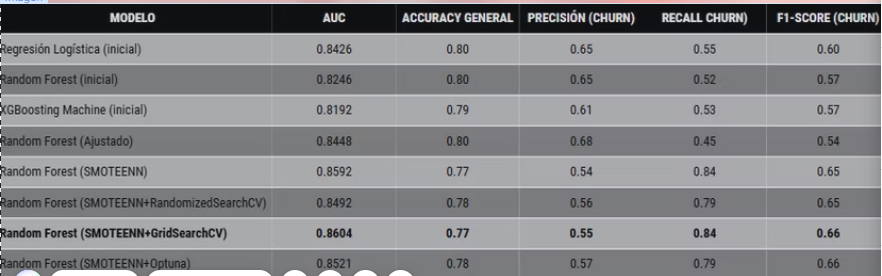

# **Conclusión**

**Importancia de las Características (Feature Importance) del Mejor Modelo**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Obtener la importancia de las características del mejor modelo (best_rf_model_grid)
feature_importances = best_rf_model_grid.feature_importances_

# Crear un DataFrame para una mejor visualización
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Ordenar las características por importancia de forma descendente
features_df = features_df.sort_values(by='Importance', ascending=False)

# Visualizar la importancia de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis')
plt.title('Importancia de las Características del Modelo Random Forest (GridSearchCV)', fontsize=16)
plt.xlabel('Importancia (Mean Decrease in Impurity)', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(features_df.head(10))

El tipo de contrato es, con diferencia, la característica más importante, con una puntuación de importancia significativamente superior a la de cualquier otra variable (aproximadamente 0,25). Esto indica que la duración/tipo de contrato del cliente (por ejemplo, mensual, anual, bianual) es el predictor más potente del modelo para maximizar la recuperación de la información. El siguiente nivel de características importantes, aunque con un impacto considerablemente menor que el del tipo de contrato, son el servicio de internet, la antigüedad, el total de cargos y la seguridad en línea.

**Visualización de la Importancia de las Características con SHAP (GridSearchCV)**

In [ ]:
import shap
import matplotlib.pyplot as plt

# Crear un explicador SHAP para el modelo Random Forest obtenido de GridSearchCV
explicador = shap.TreeExplainer(best_rf_model_grid)

# Calcular los valores SHAP para el conjunto de prueba (X_test)
shap_values = explicador.shap_values(X_test)

# También podemos ver un summary_plot con puntos para ver la dirección del impacto
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.title(
    "SHAP Importancia de las Variables\n(Random Forest - GridSearchCV)",
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

**Conclusiones:**

El modelo Random Forest, tras el ajuste de hiperparámetros, demostró ser eficaz para predecir la pérdida de clientes, ofreciendo un rendimiento estable con una recuperación promedio de validación cruzada de 0,93, un F1 Score de 0,66, y un recall de 0,84.

Si la empresa establece un estándar de recuperación de 0,85, incluso a costa de la precisión, el modelo puede ajustarse modificando el umbral de decisión para cumplir con este requisito.

La pérdida de clientes en el sector de las telecomunicaciones está influenciada principalmente por el contrato, el servicio de internet (fibra óptica), la antigüedad, los cargos por servicio (cargos totales y cargos mensuales) y la seguridad en línea. Estos hallazgos resaltan que los términos del contrato y la calidad del servicio son fundamentales para reducir la pérdida de clientes, y la empresa debería priorizar el monitoreo y la gestión de estas características para retener a los clientes de manera efectiva.


**Recomendaciones comerciales:**

Ofrecer opciones de contrato más flexibles o incentivos para que los clientes extiendan sus contratos.

Concéntrese en mejorar la calidad del servicio de fibra óptica, ofrezca paquetes combinados atractivos o promociones especiales para clientes de fibra óptica, ya que este tipo de servicio influye considerablemente en la pérdida de clientes y es el más utilizado.

Ofrezca recompensas o programas de fidelización para clientes de larga trayectoria con el fin de incentivar la retención.

Incorpore funciones de seguridad adicionales o capacitación en seguridad digital para aumentar la satisfacción del cliente.